# **Computational Intelligence for Optimization PROJECT - Group C36_Divergence**  

## **Table of Contents**

1. [Project Overview](#1-project-overview)
2. [Imports & Setup](#2-imports--setup)
3. [Load and Visualize target image](#3-load-visualize-target)
4. [Create a Random Individual](#4-random-individual)
5. [Genetic Algorithm](#5-ga) *(to be added)*
6. [Results & Analysis](#6-results) *(to be added)*

## **1. Project Overview** <a id="1-project-overview"></a>

Vermeer's *Girl with a Pearl Earring* — Genetic Algorithm reconstruction with 100 colored triangles.

Each candidate solution (an `Individual`) is a list of 100 `Triangle` objects. Each triangle is encoded as 10 floats in [0, 1] — three (x, y) vertices plus an RGBA color — and decoded to pixel/byte space at render time. Fitness is pixel-wise RMSE between the rendered phenotype and the target image (minimization).

## **2. Imports & Setup** <a id="2-imports--setup"></a>

In [2]:
# IMPORTS
# Standard
import random
import numpy as np
from time import time
from pathlib import Path
import pandas as pd

# Image handling & rendering
from PIL import Image, ImageDraw

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Project modules
from solution import *
from operators import *
from ga import *

In [3]:
# REPRODUCIBILITY
random.seed(23)
np.random.seed(23)

# SETTINGS
# Image canvas dimensions (fixed by project spec)
IMG_WIDTH  = 300
IMG_HEIGHT = 400
N_TRIANGLES = 100

## **3. Load and Visualize target image** <a id="3-load-visualize-target"></a>

In [4]:
# READ AND VISUALIZE TARGET IMAGE

IMAGE_PATH = Path("data/girl_pearl_earing.png")

# Load as RGB and convert to numpy array (H x W x 3, uint8)
target_img = Image.open(IMAGE_PATH).convert("RGB")
target_array = np.array(target_img, dtype=np.float32)  # float32 for fitness computation

print(f"Image loaded: {target_array.shape}, dtype={target_array.dtype}")
print(f"Pixel range: [{target_array.min():.0f}, {target_array.max():.0f}]")


Image loaded: (400, 300, 3), dtype=float32
Pixel range: [0, 255]


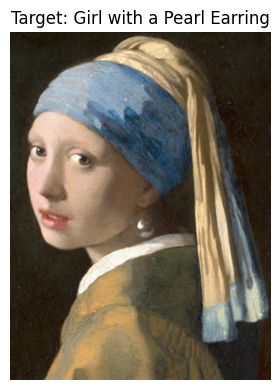

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(3,4))

axes.imshow(target_img)
axes.set_title("Target: Girl with a Pearl Earring", fontsize=12)
axes.axis("off")
plt.tight_layout()
plt.show()


## **4. Create a Random Individual** <a id="4-random-individual"></a>

A baseline sanity check: build one random `Individual`, render it, and compute its RMSE against the target. This is the *random search* baseline that the GA must beat.

Random individual RMSE vs. target: 92.38


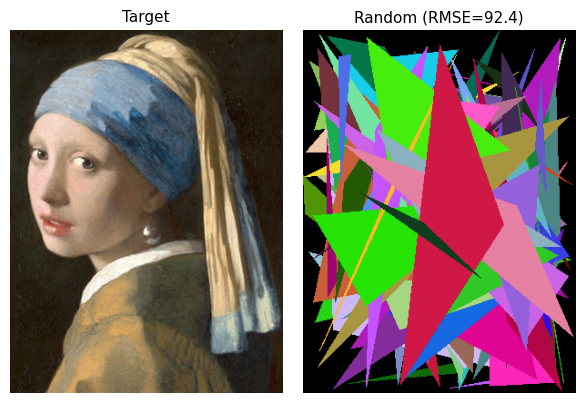

In [6]:
# Build a random Individual and evaluate it against the target.
rand_ind = Individual(target=target_array)
baseline_rmse = rand_ind.fitness()
print(f"Random individual RMSE vs. target: {baseline_rmse:.2f}")

# Side-by-side: target on the left, random phenotype on the right.
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(target_img)
axes[0].set_title("Target", fontsize=11)
axes[0].axis("off")
rand_ind.plot(ax=axes[1], title=f"Random (RMSE={baseline_rmse:.1f})")
plt.tight_layout()
plt.show()

## **5. Mutation Tests** <a id="5-mutation_tests"></a>

In [7]:
# 5. Mutation Tests
# Loop 1 — Mutation Type Comparison
# Compares triangle_mutation_vcf vs triangle_mutation_full
# Fixed hyperparameters; 5 runs per config; saves CSV + plots

# CONFIG
POP_SIZE  = 20
MAX_GENS  = 100
XO_PROB   = 0.9
MUT_PROB  = 0.05
N_RUNS    = 5
ELITISM   = True

MUTATION_CONFIGS = [
    {"name": "VCF (vertex+color+order)", "fn": triangle_mutation_vcf},
    {"name": "Full (replace triangle)",  "fn": triangle_mutation_full},
]

In [8]:
# Run the loop
all_results = []          # list of dicts → CSV
all_curves  = {}          # {config_name: list of fitness arrays, one per run}

for config in MUTATION_CONFIGS:
    config_name = config["name"]
    mut_fn      = config["fn"]
    curves      = []

    print(f"\n{'='*60}")
    print(f"  Mutation: {config_name}")
    print(f"{'='*60}")

    for run in range(1, N_RUNS + 1):
        print(f"\n  -- Run {run}/{N_RUNS} --")

        # Different seed per run for reproducibility
        seed = run * 42
        random.seed(seed)
        np.random.seed(seed)

        initial_pop = [Individual(target=target_array) for _ in range(POP_SIZE)]

        best_ind, fitness_curve = genetic_algorithm(
            initial_population  = initial_pop,
            max_generations     = MAX_GENS,
            selection_algorithm = tournament_selection,
            xo_method           = triangle_crossover,
            mut_method          = mut_fn,
            maximization        = False,
            xo_prob             = XO_PROB,
            mut_prob            = MUT_PROB,
            elitism             = ELITISM,
            verbose             = False,
        )

        curves.append(fitness_curve)

        all_results.append({
            "mutation_type" : config_name,
            "run"           : run,
            "best_fitness"  : best_ind.fitness(),
        })

        print(f"  Best final fitness: {best_ind.fitness():.4f}")

    all_curves[config_name] = curves


# Save CSV
df = pd.DataFrame(all_results)

summary = (
    df.groupby("mutation_type")["best_fitness"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "avg", "std": "std", "min": "best", "max": "worst"})
)

df.to_csv("loop1_results.csv", index=False)
print("\nResults saved to: loop1_results.csv")
print("\n--- Summary ---")
print(summary.to_string(index=False))


  Mutation: VCF (vertex+color+order)

  -- Run 1/5 --
-------------- Generation: 1/100, duration: 0.00s --------------
-------------- Generation: 2/100, duration: 0.22s --------------
-------------- Generation: 3/100, duration: 0.34s --------------
-------------- Generation: 4/100, duration: 0.54s --------------
-------------- Generation: 5/100, duration: 0.72s --------------
-------------- Generation: 6/100, duration: 0.99s --------------
-------------- Generation: 7/100, duration: 1.17s --------------
-------------- Generation: 8/100, duration: 1.33s --------------
-------------- Generation: 9/100, duration: 1.51s --------------
-------------- Generation: 10/100, duration: 1.66s --------------
-------------- Generation: 11/100, duration: 1.85s --------------
-------------- Generation: 12/100, duration: 2.04s --------------
-------------- Generation: 13/100, duration: 2.17s --------------
-------------- Generation: 14/100, duration: 2.39s --------------
-------------- Generation: 15/

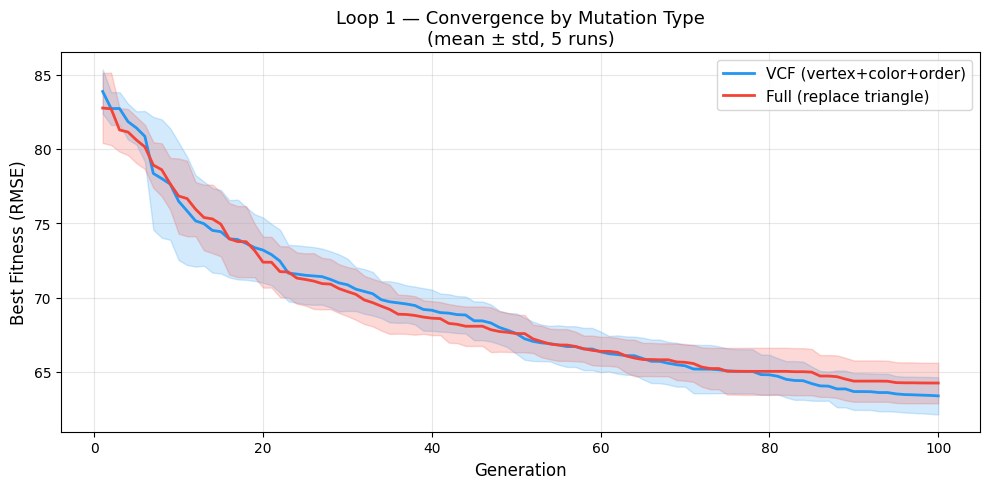

In [9]:
# Plot 1 — Convergence curves (mean ± std across runs)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2196F3", "#F44336"]

for idx, config in enumerate(MUTATION_CONFIGS):
    name   = config["name"]
    curves = np.array(all_curves[name])   # shape: (N_RUNS, MAX_GENS)
    mean   = curves.mean(axis=0)
    std    = curves.std(axis=0)
    gens   = np.arange(1, MAX_GENS + 1)
    color  = colors[idx]

    ax.plot(gens, mean, label=name, color=color, linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.2, color=color)

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best Fitness (RMSE)", fontsize=12)
ax.set_title("Loop 1 — Convergence by Mutation Type\n(mean ± std, 5 runs)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loop1_convergence.png", dpi=150)
plt.show()

/tmp/ipykernel_2238/1057923078.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


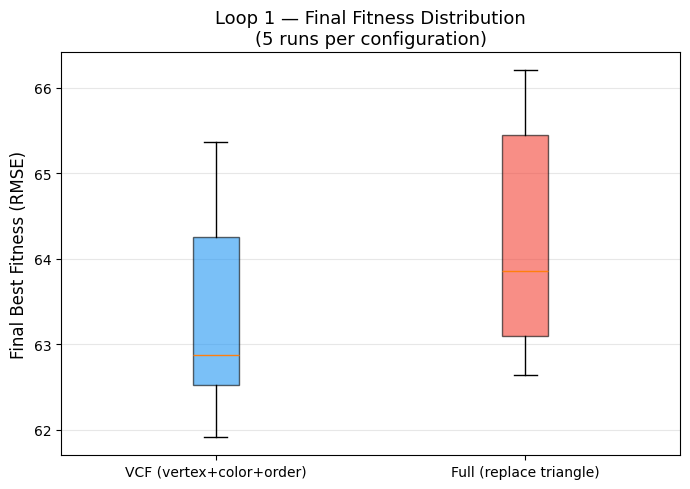

In [10]:
# Plot 2 — Boxplot of final fitness per mutation type
fig, ax = plt.subplots(figsize=(7, 5))

groups = [df[df["mutation_type"] == c["name"]]["best_fitness"].values for c in MUTATION_CONFIGS]
labels = [c["name"] for c in MUTATION_CONFIGS]

bp = ax.boxplot(groups, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Final Best Fitness (RMSE)", fontsize=12)
ax.set_title("Loop 1 — Final Fitness Distribution\n(5 runs per configuration)", fontsize=13)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("loop1_boxplot.png", dpi=150)
plt.show()